In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
# Display settings
pd.set_option("display.max_columns", None)

# Graph style
plt.style.use("ggplot")

In [2]:
# loading the file
file_path = "EduPro Online Platform.xlsx"   # file name

users = pd.read_excel(file_path, sheet_name="Users")
teachers = pd.read_excel(file_path, sheet_name="Teachers")
courses = pd.read_excel(file_path, sheet_name="Courses")
transactions = pd.read_excel(file_path, sheet_name="Transactions")

In [3]:
print("Users:", users.shape)
print("Teachers:", teachers.shape)
print("Courses:", courses.shape)
print("Transactions:", transactions.shape)

Users: (3000, 5)
Teachers: (60, 7)
Courses: (60, 8)
Transactions: (10000, 7)


In [4]:
# Viewing the dataset
users.head()
users.tail()
users.sample()

teachers.head()
teachers.tail()
teachers.sample()

courses.head()
courses.tail()
courses.sample()

transactions.head()
transactions.tail()
transactions.sample()

,TransactionID,UserID,CourseID,TransactionDate,Amount,PaymentMethod,TeacherID
7785,TT07786,U00301,CR00018,2025-04-22,0.0,Credit Card,TC00042


In [5]:
print("USERS")
users.info()

print("\nTEACHERS")
teachers.info()

print("\nCOURSES")
courses.info()

print("\nTRANSACTIONS")
transactions.info()

USERS
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   UserID    3000 non-null   object
 1   UserName  3000 non-null   object
 2   Age       3000 non-null   int64 
 3   Gender    3000 non-null   object
 4   Email     3000 non-null   object
dtypes: int64(1), object(4)
memory usage: 117.3+ KB

TEACHERS
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   TeacherID          60 non-null     object 
 1   TeacherName        60 non-null     object 
 2   Age                60 non-null     int64  
 3   Gender             60 non-null     object 
 4   Expertise          60 non-null     object 
 5   YearsOfExperience  60 non-null     int64  
 6   TeacherRating      60 non-null     float64
dtypes: float64(1), int64(

In [6]:

# check missing value of dataset
print("Users")
print(users.isnull().sum())

print("\nTeachers")
print(teachers.isnull().sum())

print("\nCourses")
print(courses.isnull().sum())

print("\nTransactions")
print(transactions.isnull().sum())

Users
UserID      0
UserName    0
Age         0
Gender      0
Email       0
dtype: int64

Teachers
TeacherID            0
TeacherName          0
Age                  0
Gender               0
Expertise            0
YearsOfExperience    0
TeacherRating        0
dtype: int64

Courses
CourseID          0
CourseName        0
CourseCategory    0
CourseType        0
CourseLevel       0
CoursePrice       0
CourseDuration    0
CourseRating      0
dtype: int64

Transactions
TransactionID      0
UserID             0
CourseID           0
TransactionDate    0
Amount             0
PaymentMethod      0
TeacherID          0
dtype: int64


In [7]:
# Handle duplicate values
print("Users :", users.duplicated().sum())
print("Teachers :", teachers.duplicated().sum())
print("Courses :", courses.duplicated().sum())
print("Transactions :", transactions.duplicated().sum())

Users : 0
Teachers : 0
Courses : 0
Transactions : 0


In [8]:
# drop duplicate agar duplicate hoga to hat jayega wo row
users.drop_duplicates(inplace=True)
teachers.drop_duplicates(inplace=True)
courses.drop_duplicates(inplace=True)
transactions.drop_duplicates(inplace=True)

In [9]:
# Statical summary
users.describe()

teachers.describe()

courses.describe()

transactions.describe()

,TransactionDate,Amount
count,10000,10000.000000
mean,2025-07-01 03:50:32.640000,91.132347
min,2025-01-01 00:00:00,0.000000
25%,2025-04-02 00:00:00,0.000000
50%,2025-06-30 00:00:00,0.000000
75%,2025-09-28 00:00:00,119.040000
max,2025-12-30 00:00:00,490.900000
std,NaN,152.063524


In [10]:
# Check columns name
print(users.columns)

print(teachers.columns)

print(courses.columns)

print(transactions.columns)

Index(['UserID', 'UserName', 'Age', 'Gender', 'Email'], dtype='object')
Index(['TeacherID', 'TeacherName', 'Age', 'Gender', 'Expertise',
       'YearsOfExperience', 'TeacherRating'],
      dtype='object')
Index(['CourseID', 'CourseName', 'CourseCategory', 'CourseType', 'CourseLevel',
       'CoursePrice', 'CourseDuration', 'CourseRating'],
      dtype='object')
Index(['TransactionID', 'UserID', 'CourseID', 'TransactionDate', 'Amount',
       'PaymentMethod', 'TeacherID'],
      dtype='object')


In [11]:


'''Step 10: Data Types (Agar Zarurat Ho)

Transaction Date ko datetime me convert karenge.'''
transactions["TransactionDate"] = pd.to_datetime(
    transactions["TransactionDate"]
)

In [12]:
# Save clean Dataset in csv
users.to_csv("users_clean.csv", index=False)
courses.to_csv("courses_clean.csv", index=False)
teachers.to_csv("teachers_clean.csv", index=False)
transactions.to_csv("transactions_clean.csv", index=False)

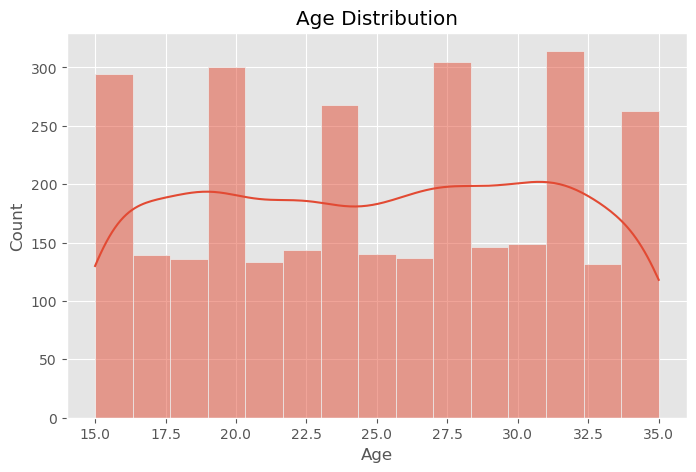

In [13]:
'''Ab Step 6: Exploratory Data Analysis (EDA)

EDA ka matlab hai data ko visualize karke samajhna.

Graph 1: Age Distribution'''

#by using seaborn
plt.figure(figsize=(8, 5))

sns.histplot(users["Age"], bins = 15, kde = True) # kde = true means ye graph pe jo red curve line h usko banane ke liye
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

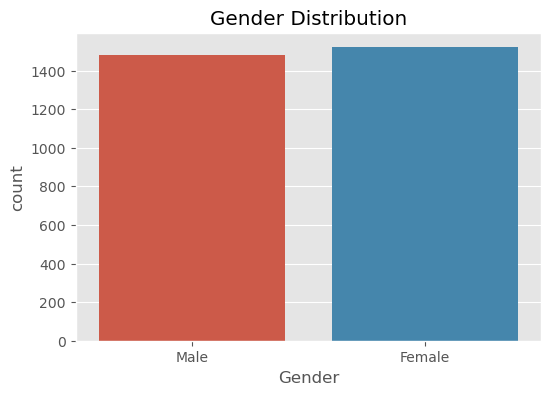

In [14]:
# Gender Distribution by using seaborn
plt.figure(figsize=(6,4))

sns.countplot(data=users, x = "Gender", hue = "Gender")

plt.title("Gender Distribution")

plt.show()

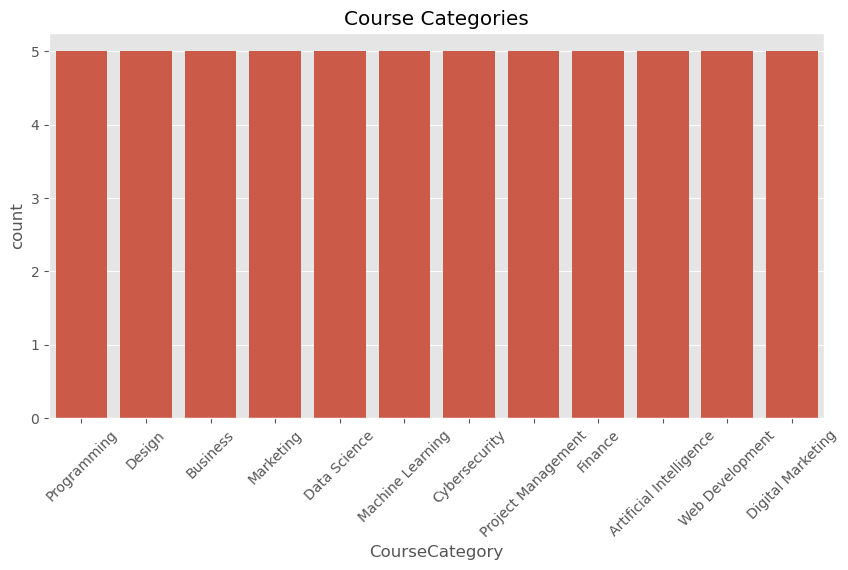

In [15]:
# Courses category Distribution
plt.figure(figsize=(10,5))

sns.countplot(data=courses,
              x="CourseCategory",
              order=courses["CourseCategory"].value_counts().index)

plt.xticks(rotation=45)

plt.title("Course Categories")

plt.show()

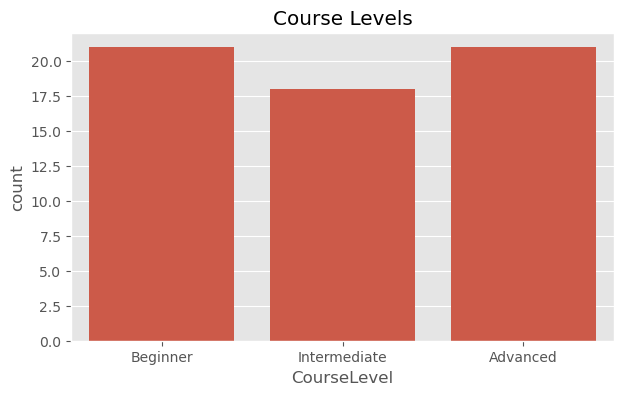

In [16]:
# Course level
plt.figure(figsize=(7,4))

sns.countplot(data=courses,
              x="CourseLevel")

plt.title("Course Levels")

plt.show()

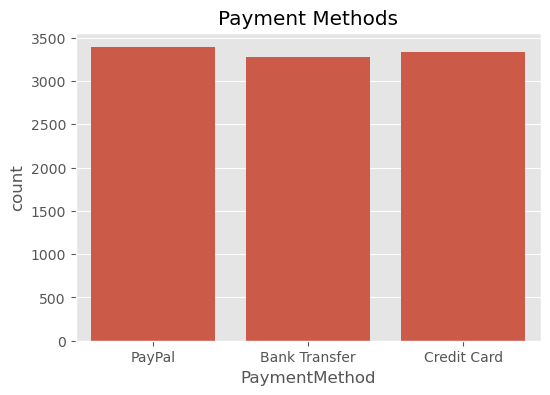

In [17]:
# Payment Method
plt.figure(figsize=(6,4))

sns.countplot(data=transactions,
              x="PaymentMethod")

plt.title("Payment Methods")

plt.show()

In [18]:
# Revenue
print("Total Revenue =", transactions["Amount"].sum())

Total Revenue = 911323.47


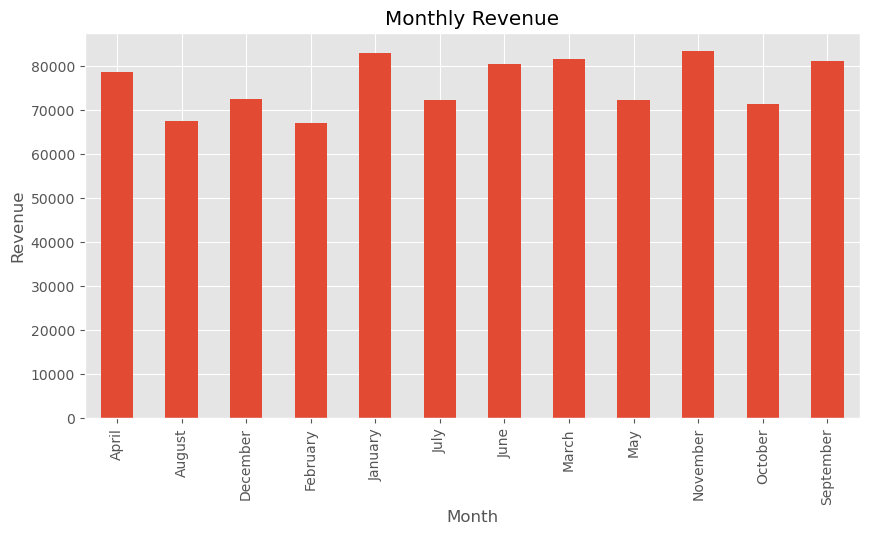

In [19]:
#monthly revenue
transactions["Month"] = transactions["TransactionDate"].dt.month_name()

monthly = transactions.groupby("Month")["Amount"].sum()

monthly.plot(kind="bar", figsize=(10,5))

plt.title("Monthly Revenue")

plt.ylabel("Revenue")

plt.show()

In [20]:
'''Feature Engineering
Feature Engineering ka matlab hai raw data se naye useful features banana. K-Means raw transactions par nahi, balki user-level features par chalega.'''
#merging transaction to course id

trans_course = transactions.merge(
    courses,
    on="CourseID",
    how="left"
)

trans_course.head()

,TransactionID,UserID,CourseID,TransactionDate,Amount,PaymentMethod,TeacherID,Month,CourseName,CourseCategory,CourseType,CourseLevel,CoursePrice,CourseDuration,CourseRating
0,TT00001,U00003,CR00016,2025-10-25,0.0,PayPal,TC00040,October,Digital Marketing,Marketing,Free,Intermediate,0.0,42.68,4.72
1,TT00002,U00003,CR00037,2025-01-13,0.0,PayPal,TC00040,January,Scrum Essentials,Project Management,Free,Intermediate,0.0,33.93,3.45
2,TT00003,U00003,CR00019,2025-03-28,0.0,Bank Transfer,TC00040,March,Content Marketing,Marketing,Free,Advanced,0.0,18.00,2.98
3,TT00004,U00004,CR00048,2025-06-02,0.0,Bank Transfer,TC00040,June,AI Ethics,Artificial Intelligence,Free,Beginner,0.0,42.70,3.64
4,TT00005,U00004,CR00060,2025-08-10,0.0,PayPal,TC00042,August,Content Creation,Digital Marketing,Free,Beginner,0.0,8.95,2.14


In [21]:
data = trans_course.merge(
    users,
    on="UserID",
    how="left"
)

data.head()

,TransactionID,UserID,CourseID,TransactionDate,Amount,PaymentMethod,TeacherID,Month,CourseName,CourseCategory,CourseType,CourseLevel,CoursePrice,CourseDuration,CourseRating,UserName,Age,Gender,Email
0,TT00001,U00003,CR00016,2025-10-25,0.0,PayPal,TC00040,October,Digital Marketing,Marketing,Free,Intermediate,0.0,42.68,4.72,morrisonamanda,33,Female,ganderson@yahoo.com
1,TT00002,U00003,CR00037,2025-01-13,0.0,PayPal,TC00040,January,Scrum Essentials,Project Management,Free,Intermediate,0.0,33.93,3.45,morrisonamanda,33,Female,ganderson@yahoo.com
2,TT00003,U00003,CR00019,2025-03-28,0.0,Bank Transfer,TC00040,March,Content Marketing,Marketing,Free,Advanced,0.0,18.00,2.98,morrisonamanda,33,Female,ganderson@yahoo.com
3,TT00004,U00004,CR00048,2025-06-02,0.0,Bank Transfer,TC00040,June,AI Ethics,Artificial Intelligence,Free,Beginner,0.0,42.70,3.64,fthornton,23,Female,christensencatherine@outlook.com
4,TT00005,U00004,CR00060,2025-08-10,0.0,PayPal,TC00042,August,Content Creation,Digital Marketing,Free,Beginner,0.0,8.95,2.14,fthornton,23,Female,christensencatherine@outlook.com


In [22]:
total_courses = data.groupby("UserID")["CourseID"].count()

total_courses.head()

UserID
U00001     1
U00002     1
U00003    11
U00004    13
U00005     2
Name: CourseID, dtype: int64

In [23]:
total_courses = total_courses.rename("TotalCourses")

In [24]:
total_spending = data.groupby("UserID")["Amount"].sum()

total_spending = total_spending.rename("TotalSpending")

In [25]:
avg_rating = data.groupby("UserID")["CourseRating"].mean()

avg_rating = avg_rating.rename("AvgCourseRating")

In [26]:
avg_price = data.groupby("UserID")["CoursePrice"].mean()

avg_price = avg_price.rename("AvgCoursePrice")

In [27]:
preferred_category = (
    data.groupby("UserID")["CourseCategory"]
        .agg(lambda x: x.mode()[0])
        .rename("PreferredCategory")
)

In [28]:
preferred_level = (
    data.groupby("UserID")["CourseLevel"]
        .agg(lambda x: x.mode()[0])
        .rename("PreferredLevel")
)

In [29]:
features = users.merge(
    total_courses,
    on="UserID",
    how="left"
)

features = features.merge(
    total_spending,
    on="UserID",
    how="left"
)

features = features.merge(
    avg_rating,
    on="UserID",
    how="left"
)

features = features.merge(
    avg_price,
    on="UserID",
    how="left"
)

features = features.merge(
    preferred_category,
    on="UserID",
    how="left"
)

features = features.merge(
    preferred_level,
    on="UserID",
    how="left"
)

features.head()

,UserID,UserName,Age,Gender,Email,TotalCourses,TotalSpending,AvgCourseRating,AvgCoursePrice,PreferredCategory,PreferredLevel
0,U00001,wilsonjordan,15,Male,patricia27@hotmail.com,1,394.26,1.350000,394.260000,Cybersecurity,Intermediate
1,U00002,angela22,29,Female,hallrandy@hotmail.com,1,0.00,2.880000,0.000000,Programming,Beginner
2,U00003,morrisonamanda,33,Female,ganderson@yahoo.com,11,613.98,2.889091,55.816364,Marketing,Advanced
3,U00004,fthornton,23,Female,christensencatherine@outlook.com,13,982.05,3.451538,75.542308,Digital Marketing,Intermediate
4,U00005,fostergeoffrey,21,Male,karenfuentes@yahoo.com,2,346.71,2.055000,173.355000,Programming,Advanced


In [30]:
features.isnull().sum()

UserID               0
UserName             0
Age                  0
Gender               0
Email                0
TotalCourses         0
TotalSpending        0
AvgCourseRating      0
AvgCoursePrice       0
PreferredCategory    0
PreferredLevel       0
dtype: int64

In [31]:
features["TotalCourses"] = features["TotalCourses"].fillna(0)

features["TotalSpending"] = features["TotalSpending"].fillna(0)

features["AvgCourseRating"] = features["AvgCourseRating"].fillna(0)

features["AvgCoursePrice"] = features["AvgCoursePrice"].fillna(0)

features["PreferredCategory"] = features["PreferredCategory"].fillna("None")

features["PreferredLevel"] = features["PreferredLevel"].fillna("None")

In [32]:
features.to_csv("user_features.csv", index=False)

In [33]:
# Encode categotical columns
from sklearn.preprocessing import LabelEncoder

le_gender = LabelEncoder()
le_category = LabelEncoder()
le_level = LabelEncoder()

features["Gender"] = le_gender.fit_transform(features["Gender"])

features["PreferredCategory"] = le_category.fit_transform(features["PreferredCategory"])

features["PreferredLevel"] = le_level.fit_transform(features["PreferredLevel"])

In [34]:
# Clustering Dataset
X = features[[
    "Age",
    "Gender",
    "TotalCourses",
    "TotalSpending",
    "AvgCourseRating",
    "AvgCoursePrice",
    "PreferredCategory",
    "PreferredLevel"
]]

In [35]:
# StandardScaler
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

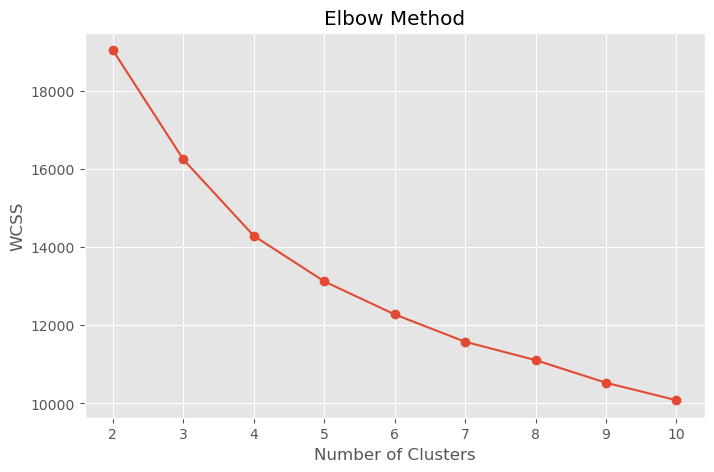

In [36]:
# Elbow Method
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for i in range(2,11):
    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(2,11), wcss, marker="o")
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [37]:
# Train K- Means
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

features["Cluster"] = kmeans.fit_predict(X_scaled)

features.head()

,UserID,UserName,Age,Gender,Email,TotalCourses,TotalSpending,AvgCourseRating,AvgCoursePrice,PreferredCategory,PreferredLevel,Cluster
0,U00001,wilsonjordan,15,1,patricia27@hotmail.com,1,394.26,1.350000,394.260000,2,2,2
1,U00002,angela22,29,0,hallrandy@hotmail.com,1,0.00,2.880000,0.000000,9,1,0
2,U00003,morrisonamanda,33,0,ganderson@yahoo.com,11,613.98,2.889091,55.816364,8,0,3
3,U00004,fthornton,23,0,christensencatherine@outlook.com,13,982.05,3.451538,75.542308,5,2,3
4,U00005,fostergeoffrey,21,1,karenfuentes@yahoo.com,2,346.71,2.055000,173.355000,9,0,1


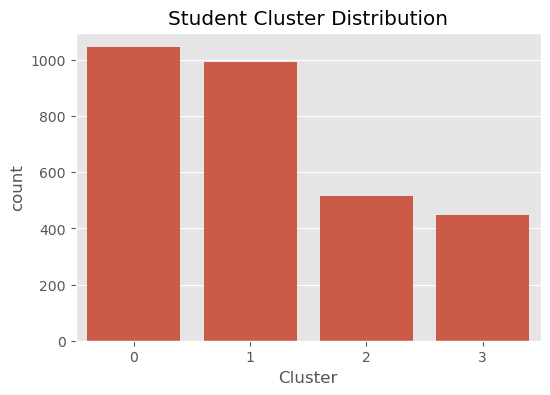

In [38]:
#Cluster Distribution
import seaborn as sns

plt.figure(figsize=(6,4))

sns.countplot(
    data=features,
    x="Cluster"
)

plt.title("Student Cluster Distribution")

plt.show()

In [39]:
# Cluster Summary
cluster_summary = features.groupby("Cluster").mean(numeric_only=True)

cluster_summary

,Age,Gender,TotalCourses,TotalSpending,AvgCourseRating,AvgCoursePrice,PreferredCategory,PreferredLevel
Cluster,,,,,,,,
0,25.073684,0.000000,1.635407,67.445445,3.168331,31.119468,4.934928,0.811483
1,24.994970,1.000000,1.550302,53.234738,3.191744,26.103090,5.004024,0.763581
2,24.764591,0.513619,1.449416,432.274572,2.967245,325.538306,3.204280,0.963035
3,24.937360,0.496644,13.434004,1265.634273,3.113537,94.501191,3.693512,0.693512


In [40]:
#cluster Naming
cluster_names = {

    0:"Budget Learners",

    1:"Professional Learners",

    2:"Premium Learners",

    3:"Casual Learners"

}

features["ClusterName"] = features["Cluster"].map(cluster_names)

In [41]:
# Save Model
import joblib

joblib.dump(kmeans, "cluster_model.pkl")

joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [42]:
# Save Final Dataset
features.to_csv("final_student_clusters.csv", index=False)

In [43]:
print(users["UserID"].head())

print(transactions["UserID"].head())

0    U00001
1    U00002
2    U00003
3    U00004
4    U00005
Name: UserID, dtype: object
0    U00003
1    U00003
2    U00003
3    U00004
4    U00004
Name: UserID, dtype: object


In [44]:
users["UserID"] = users["UserID"].astype(str).str.strip()

transactions["UserID"] = transactions["UserID"].astype(str).str.strip()

courses["CourseID"] = courses["CourseID"].astype(str).str.strip()

transactions["CourseID"] = transactions["CourseID"].astype(str).str.strip()

In [45]:
transactions["UserID"].value_counts().head()

UserID
U02976    16
U01096    16
U00216    16
U01337    16
U00427    16
Name: count, dtype: int64

In [46]:
transactions[transactions["UserID"]=="U02976"]

,TransactionID,UserID,CourseID,TransactionDate,Amount,PaymentMethod,TeacherID,Month
1748,TT01749,U02976,CR00037,2025-05-18,0.00,PayPal,TC00040,May
1749,TT01750,U02976,CR00030,2025-11-22,0.00,Bank Transfer,TC00042,November
1750,TT01751,U02976,CR00033,2025-02-07,0.00,Credit Card,TC00040,February
1751,TT01752,U02976,CR00001,2025-01-13,472.28,Bank Transfer,TC00042,January
1752,TT01753,U02976,CR00040,2025-12-01,327.99,Credit Card,TC00040,December
6112,TT06113,U02976,CR00039,2025-08-03,346.71,Credit Card,TC00042,August
6532,TT06533,U02976,CR00054,2025-09-23,0.00,Credit Card,TC00042,September
6949,TT06950,U02976,CR00003,2025-03-12,0.00,Credit Card,TC00040,March
7344,TT07345,U02976,CR00019,2025-01-10,0.00,Bank Transfer,TC00042,January
7740,TT07741,U02976,CR00010,2025-12-23,0.00,Credit Card,TC00042,December


In [47]:
def purchased_courses(user_id):

    purchased = transactions.loc[
        transactions["UserID"] == user_id,
        "CourseID"
    ].tolist()

    return purchased

In [48]:
sample_user = transactions["UserID"].iloc[0]

print(sample_user)

print(purchased_courses(sample_user))

U00003
['CR00016', 'CR00037', 'CR00019', 'CR00017', 'CR00058', 'CR00042', 'CR00018', 'CR00005', 'CR00051', 'CR00046', 'CR00040']


In [49]:
features[["UserID","PreferredCategory"]].head()

,UserID,PreferredCategory
0,U00001,2
1,U00002,9
2,U00003,8
3,U00004,5
4,U00005,9


In [50]:
def recommend_courses(user_id):

    category = features.loc[
        features["UserID"] == user_id,
        "PreferredCategory"
    ].values[0]

    bought = purchased_courses(user_id)

    recommendations = courses[
        (courses["CourseCategory"] == category) &
        (~courses["CourseID"].isin(bought))
    ]

    recommendations = recommendations.sort_values(
        by="CourseRating",
        ascending=False
    )

    return recommendations.head(5)

In [51]:
sample_user = transactions["UserID"].iloc[0]

recommend_courses(sample_user)

,CourseID,CourseName,CourseCategory,CourseType,CourseLevel,CoursePrice,CourseDuration,CourseRating


In [52]:
features["PreferredCategory"] = le_category.fit_transform(
    features["PreferredCategory"]
)

In [53]:
features[["UserID", "PreferredCategory"]].head(10)

,UserID,PreferredCategory
0,U00001,2
1,U00002,9
2,U00003,8
3,U00004,5
4,U00005,9
5,U00006,7
6,U00007,2
7,U00008,6
8,U00009,4
9,U00010,0


In [54]:
transactions.head()

,TransactionID,UserID,CourseID,TransactionDate,Amount,PaymentMethod,TeacherID,Month
0,TT00001,U00003,CR00016,2025-10-25,0.0,PayPal,TC00040,October
1,TT00002,U00003,CR00037,2025-01-13,0.0,PayPal,TC00040,January
2,TT00003,U00003,CR00019,2025-03-28,0.0,Bank Transfer,TC00040,March
3,TT00004,U00004,CR00048,2025-06-02,0.0,Bank Transfer,TC00040,June
4,TT00005,U00004,CR00060,2025-08-10,0.0,PayPal,TC00042,August


In [55]:
courses.head()

,CourseID,CourseName,CourseCategory,CourseType,CourseLevel,CoursePrice,CourseDuration,CourseRating
0,CR00001,Python Basics,Programming,Paid,Beginner,472.28,11.00,4.74
1,CR00002,Java Programming,Programming,Free,Intermediate,0.00,37.70,2.43
2,CR00003,C++ for Beginners,Programming,Free,Beginner,0.00,19.53,3.85
3,CR00004,Advanced Python,Programming,Free,Beginner,0.00,45.13,2.88
4,CR00005,Full Stack Development,Programming,Free,Beginner,0.00,28.68,1.28


In [56]:
# Transactions aur Courses ko merge karo

recommend_data = transactions.merge(
    courses,
    on="CourseID",
    how="left"
)

recommend_data.head()

,TransactionID,UserID,CourseID,TransactionDate,Amount,PaymentMethod,TeacherID,Month,CourseName,CourseCategory,CourseType,CourseLevel,CoursePrice,CourseDuration,CourseRating
0,TT00001,U00003,CR00016,2025-10-25,0.0,PayPal,TC00040,October,Digital Marketing,Marketing,Free,Intermediate,0.0,42.68,4.72
1,TT00002,U00003,CR00037,2025-01-13,0.0,PayPal,TC00040,January,Scrum Essentials,Project Management,Free,Intermediate,0.0,33.93,3.45
2,TT00003,U00003,CR00019,2025-03-28,0.0,Bank Transfer,TC00040,March,Content Marketing,Marketing,Free,Advanced,0.0,18.00,2.98
3,TT00004,U00004,CR00048,2025-06-02,0.0,Bank Transfer,TC00040,June,AI Ethics,Artificial Intelligence,Free,Beginner,0.0,42.70,3.64
4,TT00005,U00004,CR00060,2025-08-10,0.0,PayPal,TC00042,August,Content Creation,Digital Marketing,Free,Beginner,0.0,8.95,2.14


In [57]:
def recommend_courses(user_id):

    # User ke purchased courses
    purchased = recommend_data[
        recommend_data["UserID"] == user_id
    ]

    # Agar user nahi mila
    if purchased.empty:
        return "User not found"

    # Most Preferred Category
    category = purchased["CourseCategory"].mode()[0]

    # Already Purchased Courses
    purchased_courses = purchased["CourseID"].tolist()

    # Recommendation
    recommendations = courses[
        (courses["CourseCategory"] == category) &
        (~courses["CourseID"].isin(purchased_courses))
    ]

    recommendations = recommendations.sort_values(
        by="CourseRating",
        ascending=False
    )

    return recommendations[
        ["CourseID","CourseName","CourseCategory","CourseRating"]
    ].head(5)

In [58]:
transactions["UserID"].unique()[:10]

array(['U00003', 'U00004', 'U00013', 'U00015', 'U00018', 'U00028',
       'U00045', 'U00048', 'U00055', 'U00071'], dtype=object)

In [59]:
recommend_courses("U00003")

,CourseID,CourseName,CourseCategory,CourseRating
19,CR00020,Email Marketing,Marketing,4.11
